# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Rushil Nanga]

**Date:** [09/02/2028]

In [11]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airbnb = pd.read_csv("./data/airbnb_hw.csv")
airbnb.loc[
    airbnb["Price"].str.contains(",", na=False),
    "Price"
].head()

airbnb["Price"] = airbnb["Price"].str.replace(",", "", regex=False)
airbnb["Price"] = pd.to_numeric(airbnb["Price"], errors="coerce")

airbnb["Price"].isna().sum()


# In the Price variable, I found that the numbers were being stored as text, which is why numbers over 1000 included a comma. I cleaned the variable by first looking at the values over 1000 and removing the commas. Then, I converted Price to numeric. I used errors="coerce" to classify values that could not be converted into missing values. There were 0 missing values at the end.


np.int64(0)

In [48]:
police["subject_injury"].value_counts(dropna=False)

police["subject_injury"] = police["subject_injury"].where(
    police["subject_injury"].isin(["Yes", "No"])
)

missing_prop = police["subject_injury"].isna().mean()
print(missing_prop)

# I found that around 76.2% of the results are missing. That is a concern because most of the observations in the dataset do not contain information about whether the subject was injured or not.

injury_table = pd.crosstab(
    police["force_type"],
    police["subject_injury"],
    dropna=False
)

injury_table

# After cross tabulationg the subject_injury and the force_type, both Less Lethal and Maximal Restraint Technique only have missing values. Bodily Force, Chemical Irritant, and Taser have large amounts of missing values while Baton, Firearm, and Less Lethal Projectile have very little. This suggests that the amount of missing values is dependent on force_type

0.7619342359767892


subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [23]:
shark = pd.read_excel("./data/GSAF5.xls")

shark.shape
shark.columns

shark[["Unnamed: 21", "Unnamed: 22"]].notna().sum()

shark = shark.drop(columns=["Unnamed: 21", "Unnamed: 22"])

shark.shape

(7117, 21)

Minimum year: 5.0
Maximum year: 2026.0


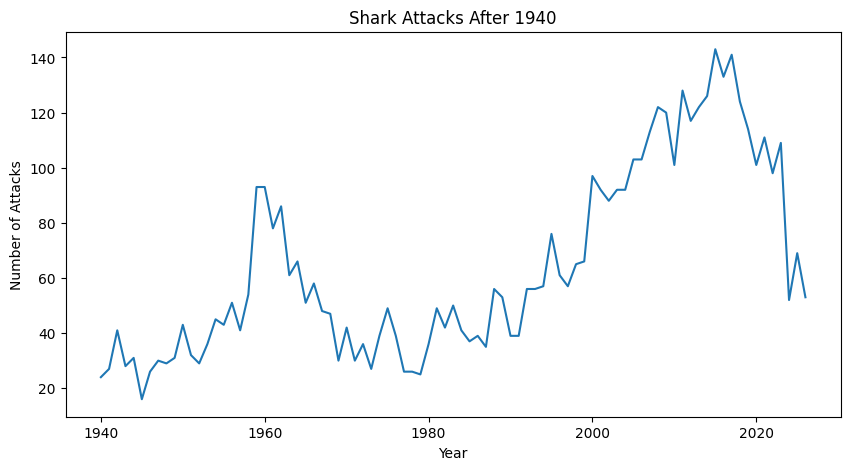

In [33]:
shark["Year"].value_counts(dropna=False).sort_index()

shark["Year"] = pd.to_numeric(
    shark["Year"],
    errors="coerce"
)

shark.loc[shark["Year"] == 0, "Year"] = np.nan

print("Earliest Year:", shark["Year"].min())
print("Recent Year:", shark["Year"].max())

shark_recent = shark[
    shark["Year"] >= 1940
].copy()

len(shark_recent)

attacks_by_year = (
    shark_recent
    .groupby("Year")
    .size()
)

attacks_by_year

plt.figure(figsize=(10, 5))

plt.plot(
    attacks_by_year.index,
    attacks_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Shark Attacks After 1940")

plt.show()

# After cleaning the data, the years range from 5 to 2026. Since 1940, the graph indicates that recorded attacks in general have increased over time, accounting for variation between years.

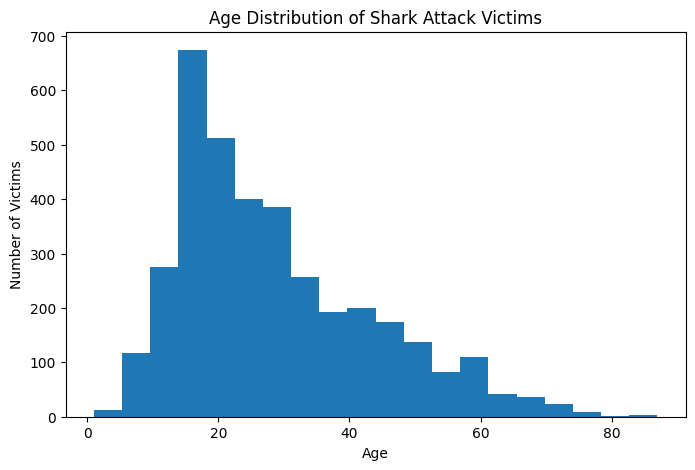

In [37]:
shark_recent["Age"].value_counts(dropna=False).head(30)

shark_recent["Age_clean"] = pd.to_numeric(
    shark_recent["Age"],
    errors="coerce"
)

shark_recent["Age_clean"].describe()

plt.figure(figsize=(8, 5))

plt.hist(
    shark_recent["Age_clean"].dropna(),
    bins=20
)

plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Age Distribution of Shark Attack Victims")

plt.show()

In [49]:
shark_recent["Sex"].value_counts(dropna=False)

shark_recent["Sex_clean"] = (
    shark_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

shark_recent["Sex_clean"] = shark_recent["Sex_clean"].where(
    shark_recent["Sex_clean"].isin(["M", "F"])
)

shark_recent["Sex_clean"].value_counts(dropna=False)

male_prop = (
    shark_recent["Sex_clean"]
    .dropna()
    .eq("M")
    .mean()
)

print(male_prop)

0.8571707317073171


In [50]:
shark_recent["Type"].value_counts(dropna=False)

type_text = (
    shark_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

shark_recent["Type_clean"] = type_text.map({
    "provoked": "Provoked",
    "unprovoked": "Unprovoked"
}).fillna("Unknown")

shark_recent["Type_clean"].value_counts()

unprovoked_prop = (
    shark_recent["Type_clean"] == "Unprovoked"
).mean()

print(unprovoked_prop)

0.7459236695932628


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]